# Styling with seaborn

We've seen instances that we use parameters such as `figsize` to control figure aesthetics in seaborn. This section organizes some of the ways that we control the representation of visualizations using seaborn. 

In [seaborn Tutorial](https://seaborn.pydata.org/tutorial.html), there are topics such as [Controlling figure aesthetics](https://seaborn.pydata.org/tutorial/aesthetics.html) that should serve as a reference.

Here we are learning the follwoing topics about seaborn styling:

| Topic | Content | Why Important |
|-------|---------|---------------|
| **Styles** | `darkgrid`, `whitegrid`, `dark`, `white`, `ticks` | Understand visual aesthetics and when each is appropriate |
| **Color Palettes** | `deep`, `muted`, `pastel`, `colorblind` | Create visually appealing and accessible plots |
| **Contexts** | `paper`, `notebook`, `talk`, `poster` | Know how to **scale** plots for different audiences/media |
| **Global vs Local** | `set_style()` vs `axes_style()` | Control scope of changes (entire session vs single plot) |

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
# %matplotlib inline
tips = sns.load_dataset('tips')

## Seaborn Figure Styles

Seaborn provides five preset themes, each designed for different use cases and aesthetic preferences.:

| Style | Description | Use Case |
|-------|-------------|----------|
| `darkgrid` | Dark background with white gridlines | Default, good for most plots |
| `whitegrid` | White background with gray gridlines | Clean, publication-ready look |
| `dark` | Dark background, no gridlines | Minimalist, modern appearance |
| `white` | White background, no gridlines | Simple, clean aesthetic |
| `ticks` | White background with tick marks on axes | Traditional scientific plots |

You set style with `sns.set_style()`, then do your plotting. Sometime, the problem is, `sns.set_style` is global, meaning it will affect all plots in the session. To take care of the problem, you can use `sns.axes_style()`, which work with context manager (the `with` statement) so that you can apply the style to individual plots. To view current style applied, use `sns.axes_style()`.

Observer the differences of the different preset styles and think about the use cases. Note that at the end of the for loop, I reset the style back to default to avoid changing the style globally. 

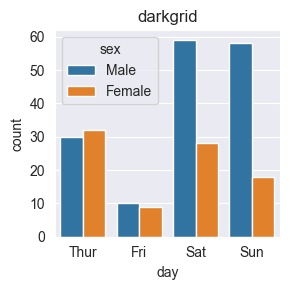

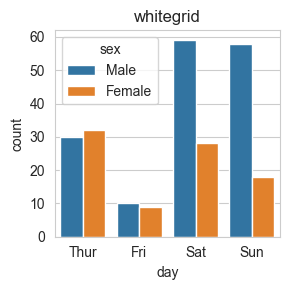

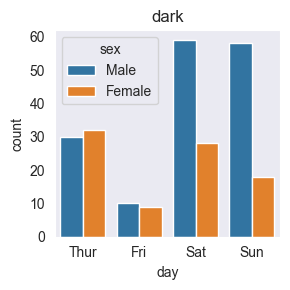

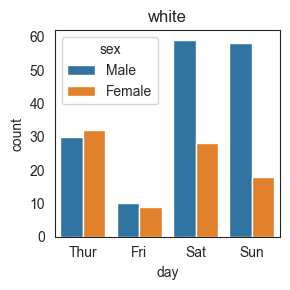

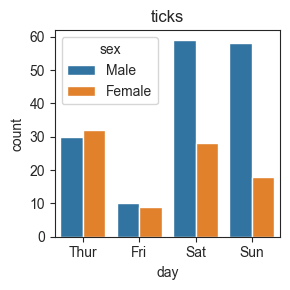

In [2]:
styles = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']
for style in (styles):
    plt.figure(figsize=[3, 3])
    sns.set_style(style)
    sns.countplot(x='day', data=tips, hue='sex')        ### count == # of rows; hue == group by and color by
    plt.title(style)
    plt.tight_layout()

sns.set_style('darkgrid')  # reset to default style


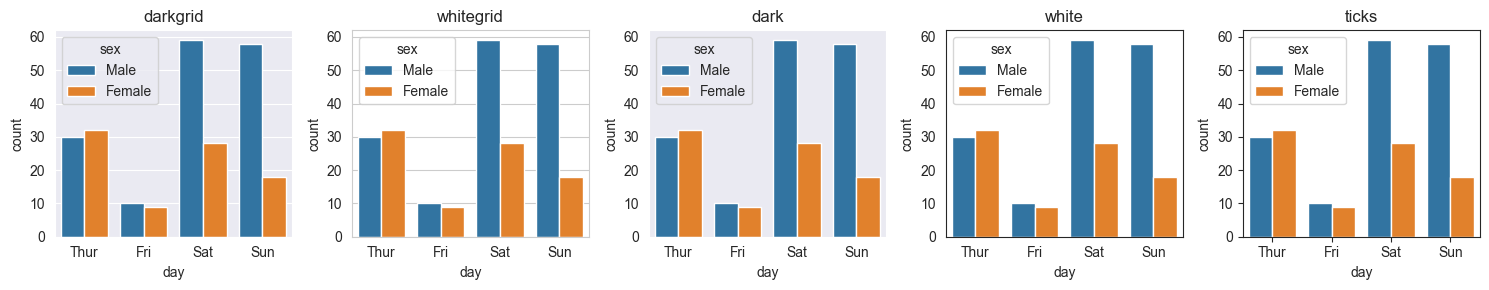

In [3]:
fig = plt.figure(figsize=(15, 3))

styles = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']
for i, style in enumerate(styles):
    with sns.axes_style(style):
        axes = plt.subplot(1, 5, i + 1)                        ### subplot(rows, cols, index) returns the axis object
        sns.countplot(x='day', hue='sex', data=tips, ax=axes)
        axes.set_title(style)
    # sns.axes_style()  # reset to default style


# sns.set_style('darkgrid')  # reset to default style
plt.tight_layout()
plt.show()

## Spine Removal

<Axes: xlabel='day', ylabel='count'>

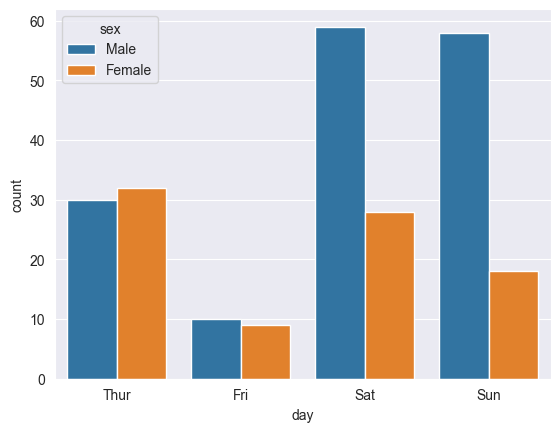

In [4]:
# sns.set_style('darkgrid')  # reset to default style

# fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# for i in range(2):
    # sns.axes_style('ticks')
    # plt.sca(axes[i])
    # sns.countplot(x='day', data=tips, hue='sex', ax=axes[i])
    # if i > 0:
    #     sns.despine()

sns.countplot(x='day', data=tips, hue='sex')
# sns.despine()

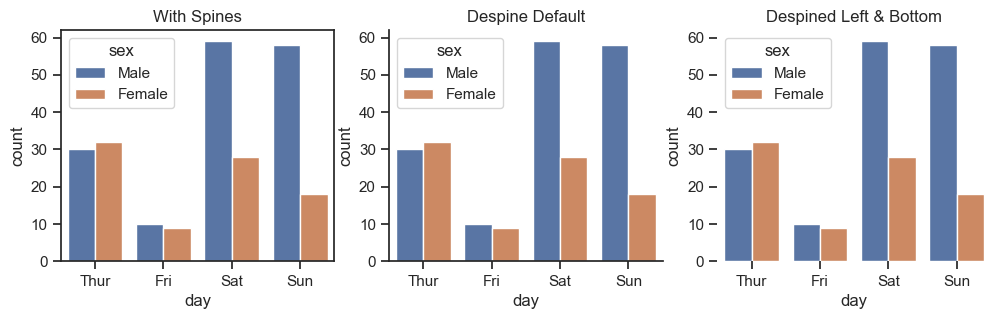

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# # Use 'white' style to see the spines more clearly
# sns.set_style("white")

# # Plot 1: With spines
# sns.countplot(x='day', hue='sex', data=tips, ax=axes[0])
# axes[0].set_title("With Spines")

# # Plot 2: Without spines (despined)
# sns.countplot(x='day', hue='sex', data=tips, ax=axes[1])
# sns.despine(ax=axes[1])
# axes[1].set_title("Despined")

# plt.tight_layout()
# plt.show()

for i in range(3):
    with sns.axes_style("ticks"):
        axes[i].set_title("With Spines" if i == 0 else "Despine Default" if i == 1 else "Despined Left & Bottom" if i == 2 else "")
        sns.countplot(x='day', data=tips, hue='sex', ax=axes[i])
        if i == 1:
            sns.despine(ax=axes[i])
        if i == 2:
            sns.despine(left=True, bottom=True, ax=axes[i])

<Axes: xlabel='sex', ylabel='count'>

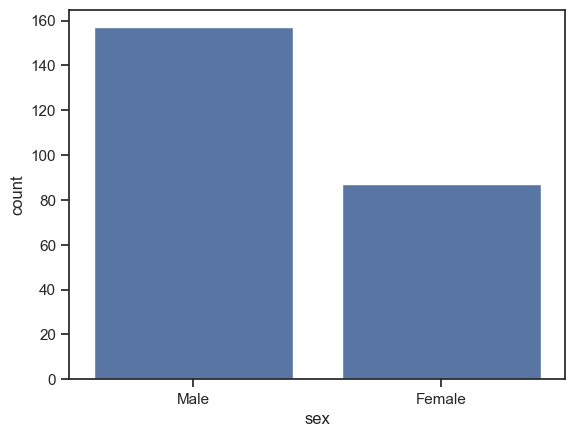

In [28]:
sns.set_style('ticks')  # reset to default style
sns.countplot(x='sex', data=tips)

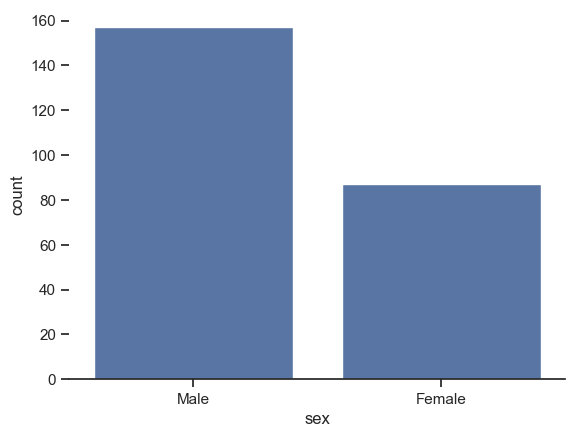

In [27]:
sns.countplot(x='sex', data=tips)
sns.despine(left=True)

## Color Pallets

/var/folders/g4/v24tl8t172g5d7rzsd63y51w0000gp/T/ipykernel_45825/989262169.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=tips, ax=axes[1], palette="pastel")


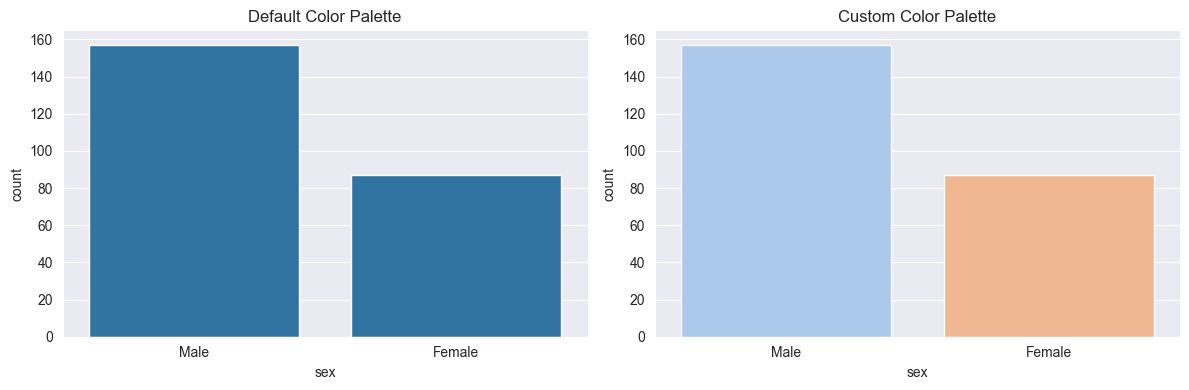

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Plot 1: Default color palette
sns.countplot(x='sex', data=tips, ax=axes[0])
axes[0].set_title("Default Color Palette")

# Plot 2: Custom color palette
sns.countplot(x='sex', data=tips, ax=axes[1], palette="pastel")
axes[1].set_title("Custom Color Palette")

plt.tight_layout()
plt.show()

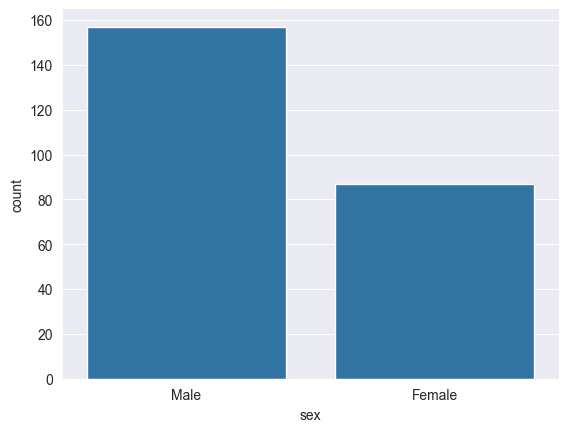

In [8]:
sns.countplot(x='sex', data=tips)
sns.despine(left=True)

## Size and Aspect

You can use matplotlib's **plt.figure(figsize=(width,height) ** to change the size of most seaborn plots.

You can control the size and aspect ratio of most seaborn grid plots by passing in parameters: size, and aspect. For example:

<Axes: xlabel='sex', ylabel='count'>

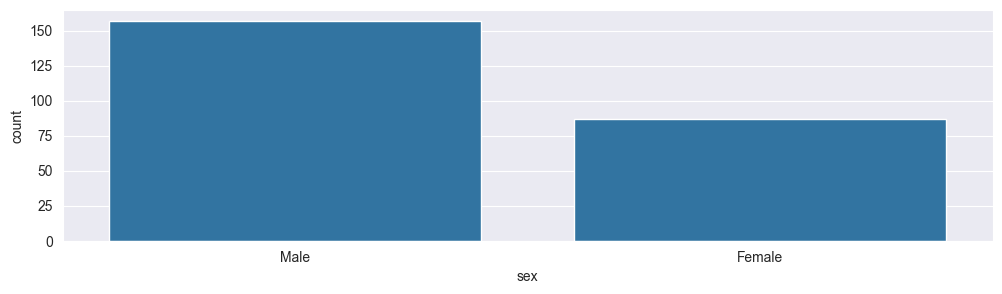

In [9]:
# Non Grid Plot
plt.figure(figsize=(12,3))
sns.countplot(x='sex',data=tips)

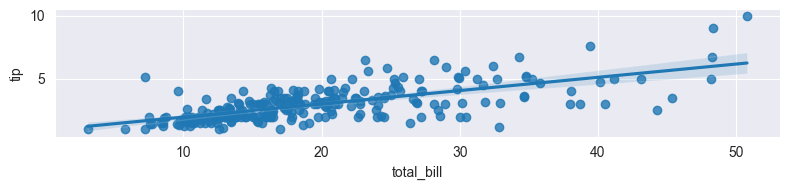

In [10]:
# Grid Type Plot
sns.lmplot(x='total_bill',y='tip', height=2, aspect=4,data=tips)

## Scale and Context

The set_context() allows you to override default parameters:

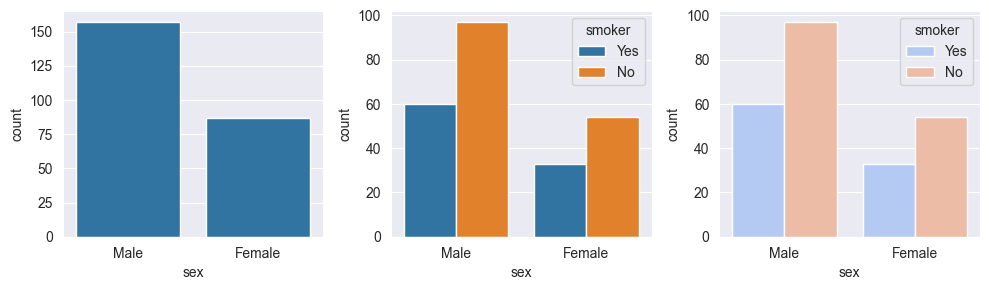

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(10,3))
sns.countplot(x='sex', data=tips, ax=ax[0])
sns.countplot(x='sex', data=tips, hue='smoker', ax=ax[1])
sns.countplot(x='sex', data=tips, hue='smoker', palette='coolwarm', ax=ax[2])
plt.tight_layout()

## Themes and Contexts

A separate set of parameters controls the scale of plot elements, allowing you to reuse the same code to create figures that are appropriately sized for different **contexts**, such as larger plots for presentations or smaller ones for papers. There are four preset contexts: 

| Context | Size | Use Case |
|---------|------|----------|
| `paper` | Smallest | Publications, journals |
| `notebook` | Medium | **Default**, Jupyter notebooks |
| `talk` | Large | Presentations, talks |
| `poster` | Largest | Posters, large displays |


To reset the parameters to default, use `sns.set_theme`.

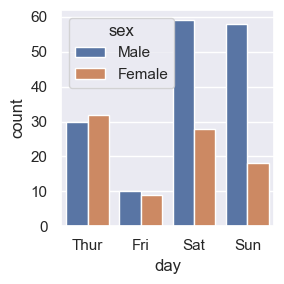

In [12]:
sns.set_theme()
# fig, axes = plt.subplots( figsize=(3,3))          ### make a new figure with specified size
plt.figure(figsize=(3,3))                           ### make a new figure with specified size
sns.countplot(x='day', hue='sex', data=tips)
plt.tight_layout()

We create a for loop to generate four plots with the four context respectively. You can see that although the `figsize` is set, the figure size and font size change along with the contexts.

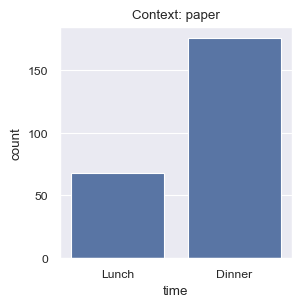

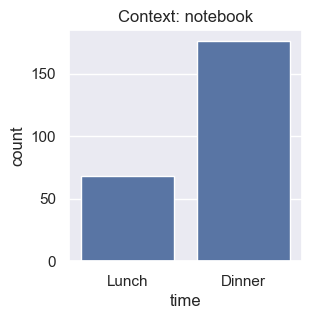

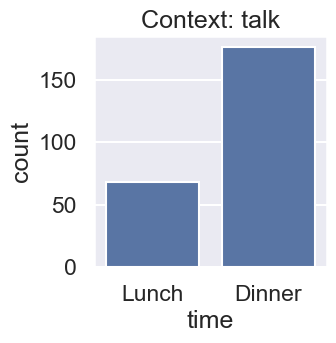

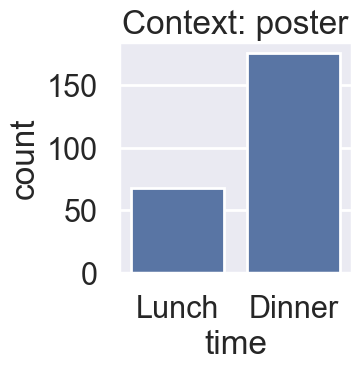

In [13]:
contexts = ['paper', 'notebook', 'talk', 'poster']  

for i in range(4):
    plt.figure(figsize=(3,3))
    sns.set_context(contexts[i])
    sns.countplot(x='time', data=tips)
    plt.title(f'Context: {contexts[i]}')

sns.set_context('notebook')  # reset to default context



You can also set font scale with context.

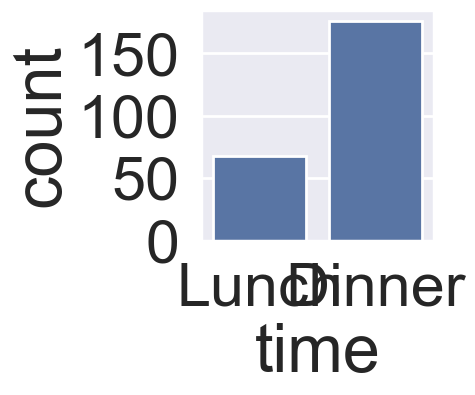

In [14]:
plt.figure(figsize=(3,3))
sns.set_context('poster', font_scale=2)
sns.countplot(x='time', data=tips)

sns.set_context('notebook')  # reset to default context

When we need the context but do not want to set it as global for the whole session, use the `with` context manager with `sns.axes_style()`.

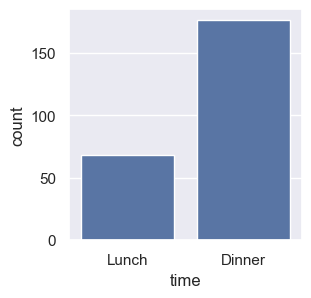

In [15]:
with sns.axes_style("darkgrid"):
    plt.figure(figsize=(3,3))
    sns.countplot(x='time', data=tips)
    plt.show()